In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from scipy.stats import skew, kurtosis

red = pd.read_csv("winequality-red.csv", sep=';')
white = pd.read_csv("winequality-white.csv", sep=';')

red["type"] = "red"
white["type"] = "white"

df = pd.concat([red, white], ignore_index=True)

print(df.head())
print(df.info())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality type  
0      9.4        5  red  
1      9.8        5  red  
2    

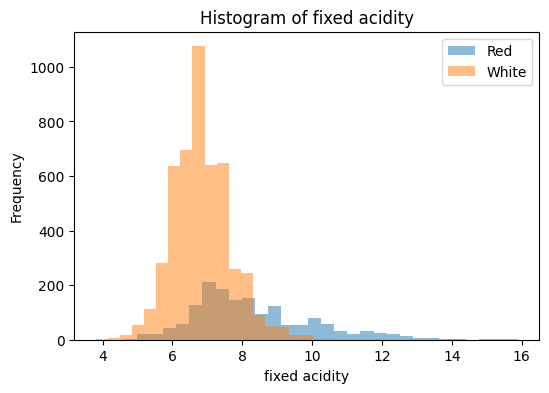

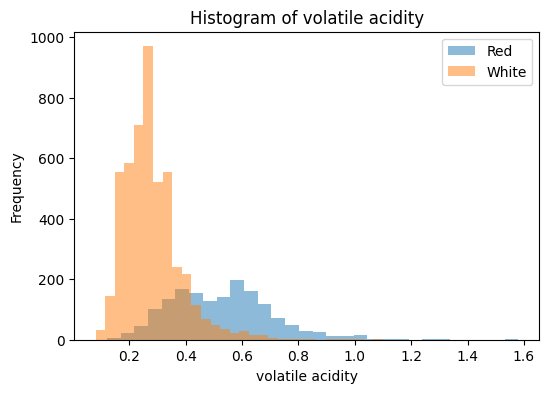

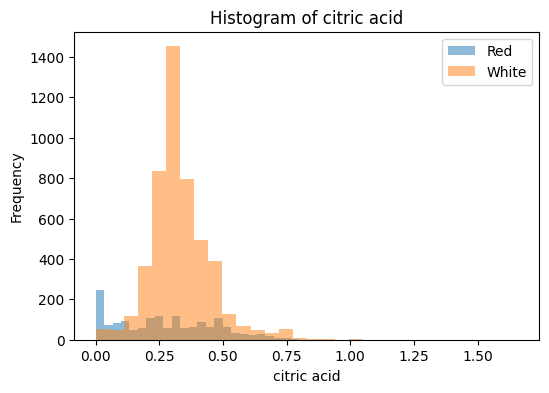

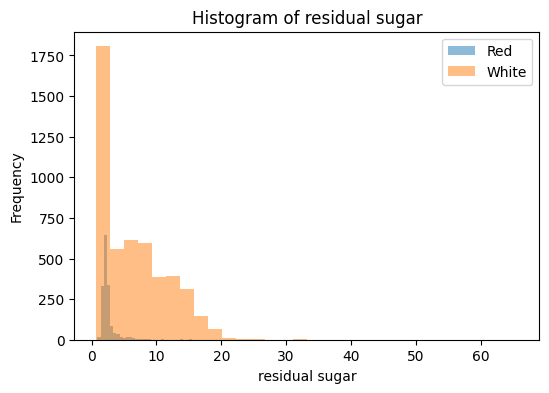

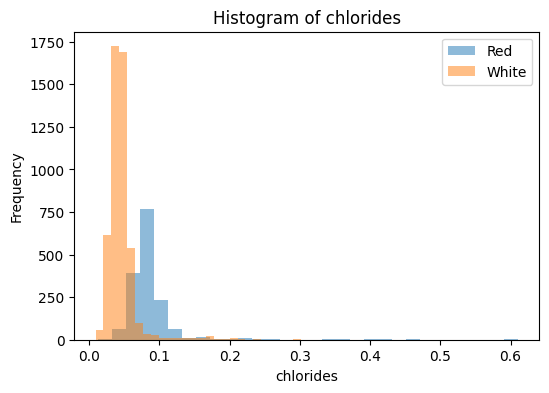

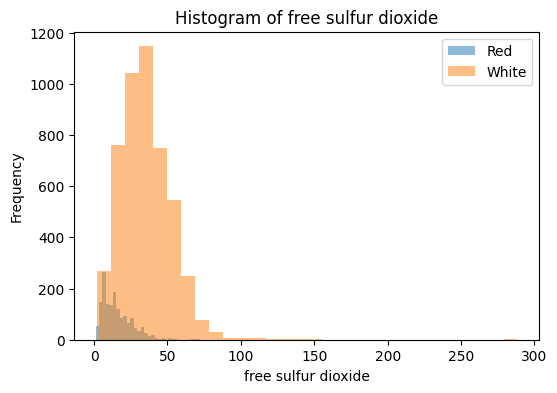

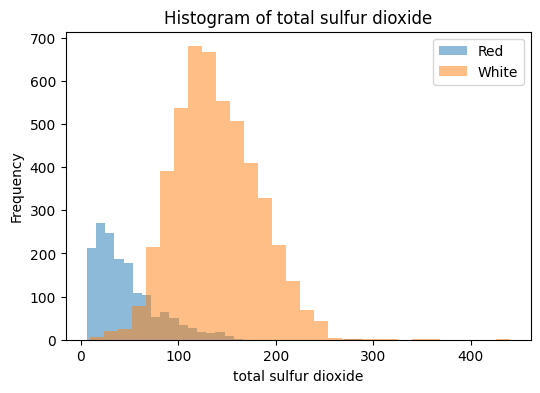

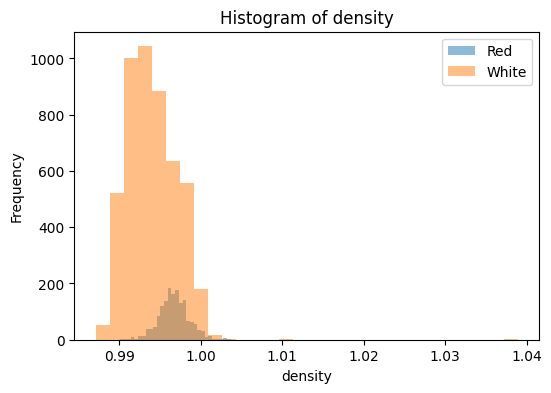

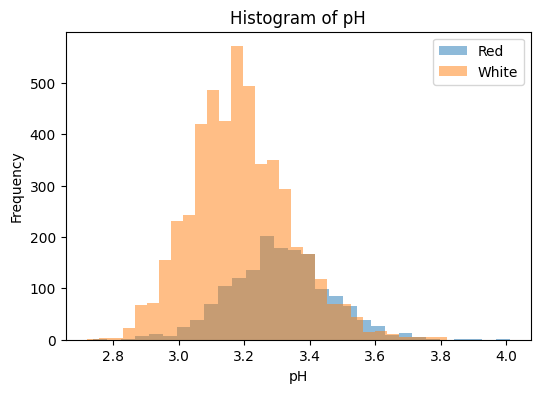

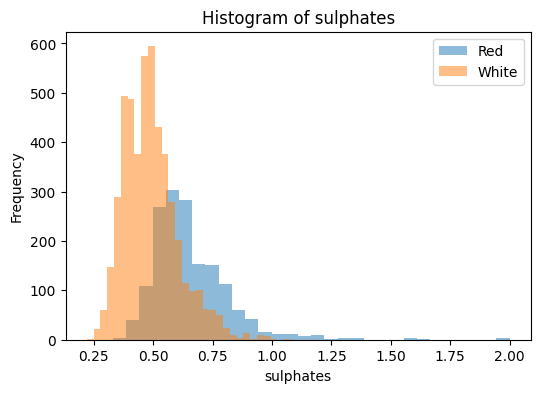

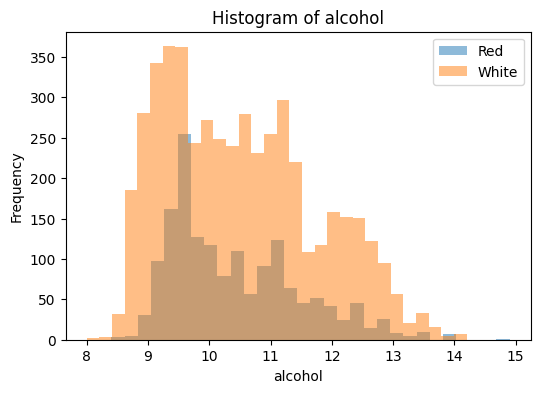

In [2]:
features = df.columns.drop(["quality", "type"])

for col in features:
    plt.figure(figsize=(6,4))
    
    plt.hist(red[col], bins=30, alpha=0.5, label="Red")
    plt.hist(white[col], bins=30, alpha=0.5, label="White")
    
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

In [3]:
def iqr(x):
  return np.percentile(x, 75) - np.percentile(x, 25)

summary = []

for col in features:
  summary.append({
    'Variable': col,
    'Red Median': red[col].median(),
    'White Median': white[col].median(),
    'Red IQR': iqr(red[col]),
    'White IQR': iqr(white[col])})

print(pd.DataFrame(summary))

print("""The ranges are not the same.
Different medians and IQRs show that red and white wines have different distributions, meaning they behave differently across wine types.""")

                Variable  Red Median  White Median    Red IQR  White IQR
0          fixed acidity     7.90000       6.80000   2.100000   1.000000
1       volatile acidity     0.52000       0.26000   0.250000   0.110000
2            citric acid     0.26000       0.32000   0.330000   0.120000
3         residual sugar     2.20000       5.20000   0.700000   8.200000
4              chlorides     0.07900       0.04300   0.020000   0.014000
5    free sulfur dioxide    14.00000      34.00000  14.000000  23.000000
6   total sulfur dioxide    38.00000     134.00000  40.000000  59.000000
7                density     0.99675       0.99374   0.002235   0.004377
8                     pH     3.31000       3.18000   0.190000   0.190000
9              sulphates     0.62000       0.47000   0.180000   0.140000
10               alcohol    10.20000      10.40000   1.600000   1.900000
The ranges are not the same.
Different medians and IQRs show that red and white wines have different distributions, meaning 

In [10]:
X = df.drop(['quality', 'type'], axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model WITHOUT scaling
model = LinearRegression()
model.fit(X_train, y_train)
print("Score without scaling:", model.score(X_test, y_test))

# Model WITH scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)
print("Score with scaling:", model_scaled.score(X_test_scaled, y_test))
print("""The variables can be used as they are, but scaling is recommended because the variables are on different scales,
which can affect model performance and interpretation.""")

Score without scaling: 0.2691465583445478
Score with scaling: 0.26914655834454637
The variables can be used as they are, but scaling is recommended because the variables are on different scales,
which can affect model performance and interpretation.



alcohol ORIGINAL skew=0.5655871101943215, kurtosis=-0.5322016529256404
alcohol MinMax skew=0.5655871101943195, kurtosis=-0.5322016529256421
alcohol Standard skew=0.5655871101943187, kurtosis=-0.5322016529256426
alcohol Robust skew=0.5655871101943185, kurtosis=-0.5322016529256435


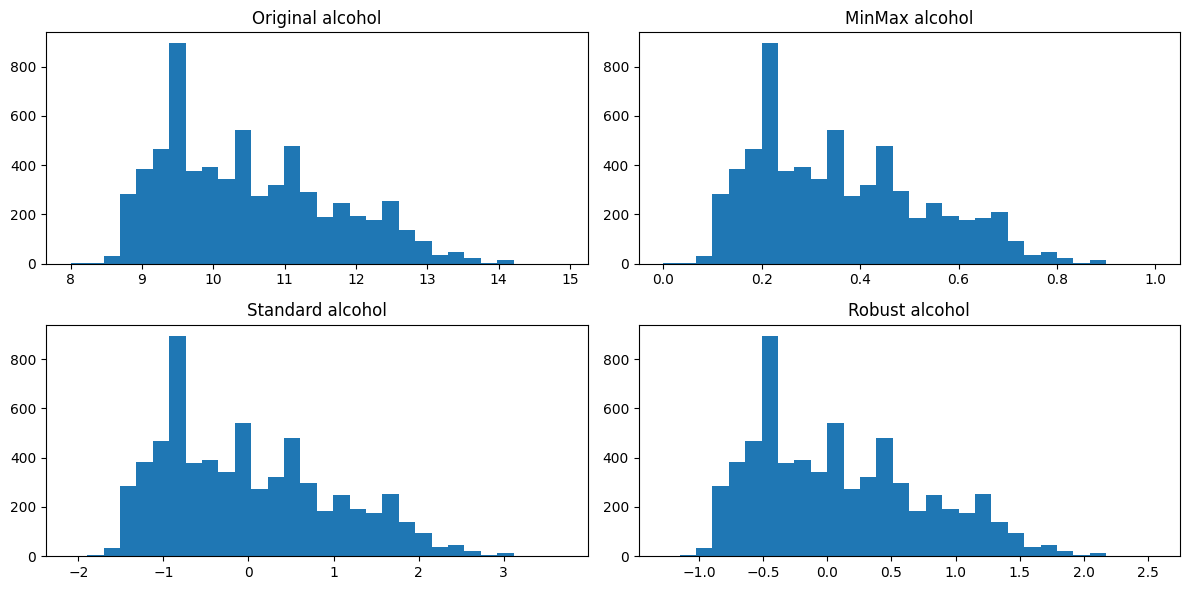


pH ORIGINAL skew=0.38674948061980574, kurtosis=0.3664510234109213
pH MinMax skew=0.3867494806197993, kurtosis=0.3664510234109173
pH Standard skew=0.38674948061979775, kurtosis=0.36645102341091773
pH Robust skew=0.38674948061979775, kurtosis=0.36645102341091684


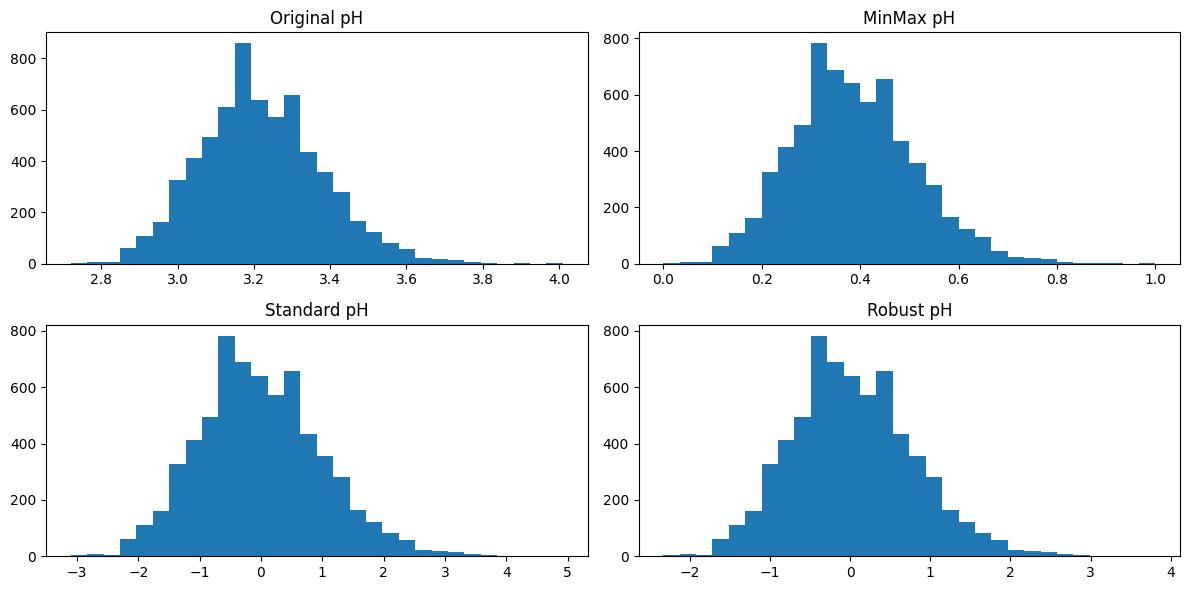

The shape remains slightly similar, but scaling changes range and spread.
Skewness and kurtosis remain mostly similar, and robust scaling handles outliers better


In [12]:
cols = ['alcohol', 'pH']

scalers = {
  'MinMax': MinMaxScaler(),
  'Standard': StandardScaler(),
  'Robust': RobustScaler()}

for col in cols:
  plt.figure(figsize=(12,6))
  
  plt.subplot(2,2,1)
  plt.hist(df[col], bins=30)
  plt.title(f'Original {col}')
    
  print(f"\n{col} ORIGINAL skew={skew(df[col])}, kurtosis={kurtosis(df[col])}")
    
  i = 2
  for name, scaler in scalers.items():
    scaled = scaler.fit_transform(df[[col]])
        
    plt.subplot(2,2,i)
    plt.hist(scaled, bins=30)
    plt.title(f'{name} {col}')
        
    print(f"{col} {name} skew={skew(scaled.flatten())}, kurtosis={kurtosis(scaled.flatten())}")
        
    i += 1
    
  plt.tight_layout()
  plt.show()

print("""The shape remains slightly similar, but scaling changes range and spread.
Skewness and kurtosis remain mostly similar, and robust scaling handles outliers better""")

In [17]:
diffs = {}

for col in features:
  diff = abs(red[col].mean() - white[col].mean())
  diffs[col] = diff

# Sort variables
sorted_diffs = sorted(diffs.items(), key=lambda x: x[1], reverse=True)

print("Top discriminating variables:")
for var, val in sorted_diffs[:5]:
  print(var, val)

print("""I first calculated the difference in means between red and white wines for each variable and then ranked said variables by largest difference
this gave me that the variables with the largest difference are alcohol, density, or sulphates, and in other words:
These are the best discriminates between wine types that separates the two classes most clearly""")

Top discriminating variables:
total sulfur dioxide 91.89286504095685
free sulfur dioxide 19.433163106484223
residual sugar 3.852609359769824
fixed acidity 1.4648496048597126
volatile acidity 0.24957939399650303
I first calculated the difference in means between red and white wines for each variable and then ranked said variables by largest difference
this gave me that the variables with the largest difference are alcohol, density, or sulphates, and in other words:
These are the best discriminates between wine types that separates the two classes most clearly
